## Orcapod DEMO

A framework for fully traceable and reproducible scientific computation

## Guiding Principles

- Reproducibility
- Performance
- Simplicity
- Flexibility
- Extensibility
- Reusability
- Robustness

## Build (if changed)

In [37]:
!cd ../../.. && maturin develop --uv

📦 Including license file `LICENSE`
🔗 Found uniffi bindings
📡 Using build options features from pyproject.toml
   Compiling orcapod v0.1.0 (/workspaces/orcapod-pipeline-old-tutorial)
    Finished `dev` profile [unoptimized + debuginfo] target(s) in 29.91s      
   Compiling orcapod v0.1.0 (/workspaces/orcapod-pipeline-old-tutorial)
    Finished `dev` profile [unoptimized + debuginfo] target(s) in 31.96s   
     Running `target/debug/uniffi-bindgen generate --no-format --language python --out-dir /workspaces/orcapod-pipeline-old-tutorial/target/maturin/uniffi/orcapod --library /workspaces/orcapod-pipeline-old-tutorial/target/debug/liborcapod.so`
📦 Built wheel to /tmp/.tmpOlIcF5/orcapod-0.1.0-py3-none-linux_x86_64.whl
✏️ Setting installed package as editable
🛠 Installed orcapod-0.1.0


## Monitors

In [1]:
# monitor containers
# watch -n 0.5 docker ps -a

# monitor last container
# watch -n 2 'docker logs "$(docker ps -q --latest)"'

# remove closed containers
# docker rm $(dockr ps -a -q)

# monitor agent network

# clear && python -c 'import asyncio; from orcapod import AgentClient; client = AgentClient(group="test", host="alpha"); asyncio.run(client.watch(key_expr="**"))'

## Imports

In [2]:
import asyncio
import csv
import json
import random
from datetime import datetime, timezone
from pathlib import Path
from textwrap import dedent

from orcapod import (
    Agent,
    AgentClient,
    Blob,
    BlobKind,
    InputSpecUri,
    Kernel,
    LocalDockerOrchestrator,
    LocalFileStore,
    OutputSpecUri,
    Packet,
    PathInfo,
    PathSet,
    Pipeline,
    PipelineJob,
    Pod,
    PodJob,
    Uri,
)

## Config

In [3]:
namespace_lookup = {"default": "../../.tmp"}
root_dir = "test"
data_dir = f"{root_dir}/data"
store_dir = f"{root_dir}/store"

In [4]:
group = "test"
host = "alpha"

## Utils

In [5]:
from collections.abc import Awaitable


async def print_crash(long_task: Awaitable):
    try:
        return await long_task
    except Exception as exception:
        print(f"{long_task.__name__} CRASHED: {exception}")

In [6]:
import subprocess
from IPython.display import SVG


def display_dot(dot_data: str):
    svg_bytes, _ = subprocess.Popen(
        ["dot", "-T", "svg"],
        stdin=subprocess.PIPE,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
    ).communicate(dot_data.encode())

    return SVG(data=svg_bytes)

In [7]:
from IPython.display import display, clear_output
from time import sleep
from collections.abc import Callable


def animate_display(next_display_object: Callable):
    while display_object := next_display_object():
        clear_output()
        display_handle = display(display_id="current")
        display_handle.update(display_object)
        sleep(0.1)

## Setup

Makes parameter files, and some test data.

In [8]:
config_dir = Path(namespace_lookup["default"]) / data_dir / "configs"
config_dir.mkdir(parents=True, exist_ok=True)

# Save parameter files
params = {
    "filter_width": 3,
    "spike_threshold": 3.0,
    "error_threshold": 100.0,
}
with open(config_dir / "1.json", "w") as f:
    json.dump(params, f, indent=2)

params.update({"filter_width": 4})

with open(config_dir / "2.json", "w") as f:
    json.dump(params, f, indent=2)

NUM_FILES = 3  # Later, increase to see error
ERROR_SUBJ = 4


# Generate a dummy ephys trace
def generate_dummy_trace(n_samples=12, seed=0):
    random.seed(seed)

    noise = [random.gauss(0, 0.5) for _ in range(n_samples)]
    spike_train = [0.0] * n_samples
    for _ in range(seed + 1):
        spike_idx = random.randrange(n_samples)
        spike_train[spike_idx] = 10  # fake spike
    trace = [n + s for n, s in zip(noise, spike_train)]

    if seed % 2 == 1:  # For demonstrating speed variance
        trace[0] = 1.0
    if seed == ERROR_SUBJ:  # For later error detection
        trace[3] = 999.0

    return trace


input_dir = Path(namespace_lookup["default"]) / data_dir / "subjects"
input_dir.mkdir(parents=True, exist_ok=True)

for i in range(1, NUM_FILES + 1):
    trace = generate_dummy_trace(seed=i)
    with open(input_dir / f"{i}.csv", "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(trace)

`smooth_pod` -  Simple computation that:
- Loads a trace file
- Loads a config file
- Sleep for 10s if the first value is exactly `1`
- Crash if any trace value is greater than `error_threshold`
- Perform smoothing on the trace

In [9]:
smooth_pod = Pod(
    image="python:3.12-slim",
    command=[
        "bash",
        "-c",
        "umask u=rwx,g=rwx,o=rwx && python -c '{}'".format(
            dedent(
                """
                import csv
                import json 
                import statistics
                from time import sleep
                from pathlib import Path

                for trace_file in Path("/tmp/input/traces").glob("*"):
                    trace = [float(x) for row in csv.reader(trace_file.open()) for x in row if x.strip()]

                    for config_file in Path("/tmp/input/configs").glob("*"):
                        config = json.load(config_file.open())

                        # Simulated error checks
                        if trace and trace[0] == 1.0:
                            sleep(10)
                        if any(val > config.get("error_threshold", float("inf")) for val in trace):
                            raise Exception("Intentional error")

                        # Moving average smoothing
                        def moving_average(data, width=3):
                            smoothed = []
                            half = width // 2
                            for i in range(len(data)):
                                window = data[max(0, i - half) : min(len(data), i + half + 1)]
                                smoothed.append(statistics.mean(window))
                            return smoothed

                        filter_width = config.get("filter_width", 3)
                        smoothed = moving_average(trace, filter_width)

                        save_dir = f"/tmp/output/config{config_file.stem}"
                        Path(save_dir).mkdir(parents=True, exist_ok=True)
                        with open(f"{save_dir}/subj_{trace_file.stem}.csv", "w", newline="") as smooth_file:
                            writer = csv.writer(smooth_file)
                            writer.writerow(smoothed)

                        print(f"Trace: {trace}")
                        print(f"Config: {config}")
                        print(f"Smoothed: {smoothed}")
                """
            ).strip()
        ),
    ],
    input_spec={
        "traces": PathInfo(path="/tmp/input/traces", match_pattern=".*\.csv"),
        "configs": PathInfo(path="/tmp/input/configs", match_pattern=".*\.json"),
    },
    output_dir="/tmp/output/",
    output_spec={"smooth": PathInfo(path=".", match_pattern=".*\.csv")},
    source_commit_url="https://place.holder",
    recommended_cpus=0.1,
    recommended_memory=10 << 20,
)

`spike_pod` -  Simple computation that:
- Loads a trace file
- Loads a config file
- Finds/saves trace indices over `spike_threshold`

In [10]:
spike_pod = Pod(
    image="python:3.13-slim",
    command=[
        "bash",
        "-c",
        "umask u=rwx,g=rwx,o=rwx && python -c '{}'".format(
            dedent(
                """ 
                import csv
                import json
                from pathlib import Path

                for trace_file in Path("/tmp/input/smooth").glob("**/*.csv"):
                    trace = [float(x) for row in csv.reader(trace_file.open()) for x in row if x.strip()]

                    for config_file in Path("/tmp/input/configs").glob("*"):
                        config = json.load(config_file.open())

                        spike_threshold = config.get("spike_threshold", float("inf"))
                        print(f"Trace: {trace}")
                        spikes = [i for i, val in enumerate(trace) if val > spike_threshold]

                        save_dir = f"/tmp/output/config{config_file.stem}"
                        Path(save_dir).mkdir(parents=True, exist_ok=True)
                        with open(f"{save_dir}/{trace_file.stem}.csv", "w", newline="") as spike_file:
                            writer = csv.writer(spike_file)
                            writer.writerow(spikes)

                        print(f"Spikes: {spikes}")
                """
            ).strip()
        ),
    ],
    input_spec={
        "smooth": PathInfo(path="/tmp/input/smooth", match_pattern=".*\.csv"),
        "configs": PathInfo(path="/tmp/input/configs", match_pattern=".*\.json"),
    },
    output_dir="/tmp/output/",
    output_spec={"spikes": PathInfo(path=".", match_pattern=".*\.csv")},
    source_commit_url="https://place.holder",
    recommended_cpus=0.1,
    recommended_memory=10 << 20,
)

In [11]:
orch = LocalDockerOrchestrator()

In [12]:
store = LocalFileStore(directory=f'{Path(namespace_lookup["default"])}/{store_dir}')

## `PodJob` Test

In [13]:
smooth_pod_job = PodJob(
    pod=smooth_pod,
    input_packet=Packet(
        {
            "traces": PathSet.COLLECTION(
                blobs=[
                    Blob(
                        kind=BlobKind.FILE,
                        location=Uri(
                            namespace="default", path=f"{data_dir}/subjects/2.csv"
                        ),
                        checksum="",
                    )
                ]
            ),
            "configs": PathSet.COLLECTION(
                blobs=[
                    Blob(
                        kind=BlobKind.FILE,
                        location=Uri(
                            namespace="default", path=f"{data_dir}/configs/1.json"
                        ),
                        checksum="",
                    )
                ]
            ),
        }
    ),
    output_dir=Uri(namespace="default", path=f"{data_dir}/smooth"),
    cpu_limit=0.1,
    memory_limit=10 << 20,
    namespace_lookup=namespace_lookup,
)

In [14]:
pod_run = await orch.start(namespace_lookup=namespace_lookup, pod_job=smooth_pod_job)

In [15]:
pod_result = await orch.get_result(namespace_lookup=namespace_lookup, pod_run=pod_run)

In [16]:
pod_result.status

In [17]:
await orch.delete(pod_run=pod_run)

In [18]:
# REMOVE LATER
# Checking that spikes pod works

spike_pod_job = PodJob(
    pod=spike_pod,
    input_packet=Packet(
        {
            "smooth": PathSet.COLLECTION(
                blobs=[
                    Blob(
                        kind=BlobKind.FILE,
                        location=Uri(
                            namespace="default",
                            path=f"{data_dir}/smooth/config1/subj_2.csv",
                        ),
                        checksum="",
                    )
                ]
            ),
            "configs": PathSet.COLLECTION(
                blobs=[
                    Blob(
                        kind=BlobKind.FILE,
                        location=Uri(
                            namespace="default", path=f"{data_dir}/configs/1.json"
                        ),
                        checksum="",
                    )
                ]
            ),
        }
    ),
    output_dir=Uri(namespace="default", path=f"{data_dir}/spikes"),
    cpu_limit=0.1,
    memory_limit=10 << 20,
    namespace_lookup=namespace_lookup,
)

In [19]:
pod_run = await orch.start(namespace_lookup=namespace_lookup, pod_job=spike_pod_job)

In [20]:
await orch.delete(pod_run=pod_run)

## `PipelineJob` Test

Configuration for operator that renames packet keys i.e. `MapOperator`.

In [21]:
map_left = {"answer": "left"}
map_right = {"answer": "right"}

Compute pipeline that chains several `add_pod` computations.

In [22]:
pipeline = Pipeline(
    graph_dot="""
    digraph {
        { smooth input } -> join -> spike
    }
    """,
    metadata={
        "smooth": Kernel.POD(ref=smooth_pod),
        "input": Kernel.MAP_OPERATOR(map={}),
        "join": Kernel.JOIN_OPERATOR(),
        "spike": Kernel.POD(ref=spike_pod),
    },
    input_spec={
        "traces": [InputSpecUri(node="smooth", key="traces")],
        "configs": [
            InputSpecUri(node="smooth", key="configs"),
            InputSpecUri(node="input", key="configs"),
        ],
    },
    output_spec={"answer": OutputSpecUri(node="spike", key="spikes")},
)

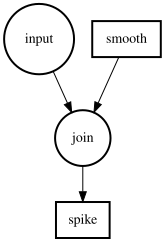

In [23]:
display_dot(dot_data=pipeline.make_dot())

In [ ]:
pipeline_job = PipelineJob(
    pipeline=pipeline,
    input_packet={
        "traces": [
            PathSet.COLLECTION(
                blobs=[
                    Blob(
                        kind=BlobKind.FILE,
                        location=Uri(
                            namespace="default", path=f"{data_dir}/subjects/{i}.csv"
                        ),
                        checksum="",
                    )
                ]
            )
            for i in range(1, NUM_FILES + 1)
        ],
        "configs": [
            PathSet.COLLECTION(
                blobs=[
                    Blob(
                        kind=BlobKind.FILE,
                        location=Uri(
                            namespace="default", path=f"{data_dir}/configs/{i}.json"
                        ),
                        checksum="",
                    )
                ]
            )
            for i in (1, 2)
        ],
    },
    output_dir=Uri(namespace="default", path=f"{data_dir}/spike_pipeline"),
    namespace_lookup=namespace_lookup,
)

In [25]:
# pipeline_job.input_packet()
pipeline_job.input_packet()["traces"][0].blobs[0].checksum

'c5c66f4cddd21e75fbe03244af721b23345de4bbfd2466f4498e4c9f17b00c48'

In [26]:
client = AgentClient(group=group, host=host)
agent = Agent(group=group, host=host, orchestrator=orch)

In [27]:
worker = asyncio.create_task(
    print_crash(agent.start(namespace_lookup=namespace_lookup, available_store=store))
)

In [34]:
pipeline_run = await client.start_pipeline_job(pipeline_job=pipeline_job)

In [35]:
{
    "created": pipeline_run.created(),
    "status": pipeline_run.status(),
    "terminated": pipeline_run.terminated(),
}

{'created': 1758856889,
 'status': <PipelineStatus.RUNNING: 2>,
 'terminated': None}

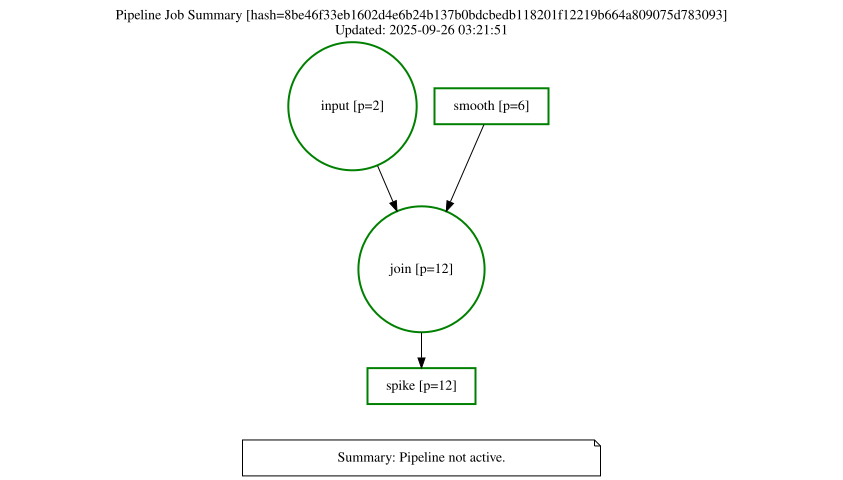

In [36]:
animate_display(
    next_display_object=lambda: (
        display_dot(dot_data=pipeline_run.summarize_dot())
        if not pipeline_run.terminated()
        or datetime.now(timezone.utc).timestamp() <= pipeline_run.terminated() + 2
        else None
    )
)

In [31]:
pipeline_result = await client.get_pipeline_result(pipeline_run=pipeline_run)

In [32]:
{
    "created": pipeline_result.created,
    "status": pipeline_result.status,
    "terminated": pipeline_result.terminated,
}

{'created': 1758856798,
 'status': <PipelineStatus.COMPLETED: 0>,
 'terminated': 1758856820}

In [33]:
# print(pipeline_run.summarize_dot())

## Roadmap

- Educational / Pitching Content
- Simpler, python-friendly experience
- Pipeline of pipelines
- Kubernetes orchestrator
- Queries and data exploration
- Dashboard GUIs
- Multi-agent support
- Tags
- Memoization
- Filter operator
- Agent resource limits
- Support external extensibility

## Competitor Review

- DataJoint
- Flyte
- Prefect
- ZenML

Many more in [awesome-pipeline](https://github.com/pditommaso/awesome-pipeline)

## Teardown

In [ ]:
import shutil

In [ ]:
shutil.rmtree(Path(namespace_lookup["default"]) / data_dir / "output")

In [ ]:
shutil.rmtree(Path(namespace_lookup["default"]) / root_dir)